## Plotting the Synthetic Observations

In [1]:
import sys
sys.path.append('../src')
from realstar_synthetic_observations import Observations
import torch
import os
import numpy as np

#for interactive plotting
#%matplotlib widget 
import matplotlib.pyplot as plt


In [2]:
val_data_file = 'SPIRou06_val.df'
nspec = 3  #changes the number of observations you generate
order = 6  # if you change this, change the validation file too

obs = Observations(i=0, seed=0, SNR=50, filepath="../data/validation_data/"+val_data_file, N=nspec,order=order,star='barnards')
synthetic_spectra, uncertainty = obs.make_observations(func='connors', add_RV=True)
synthetic_spectra, uncertainty = obs.post_process()
non_ones = torch.where(obs.padded_wgrid != 1)

In [3]:
# wavelength grid for the synthetic observations
print(len(obs.inst_wgrid))
inst_wgrid = obs.inst_wgrid.cpu().numpy()

print(f'The wavelength range is {inst_wgrid[0]:.4f}nm to {inst_wgrid[-1]:.4f}nm')

4088
The wavelength range is 1034.6336nm to 1067.4483nm


In [4]:
#we need to convert the tensor to a numpy array and move the data to CPU

synthetic_spectra = synthetic_spectra[0].cpu().numpy()
np.shape(synthetic_spectra)

(3, 4088)

<Figure size 640x480 with 0 Axes>

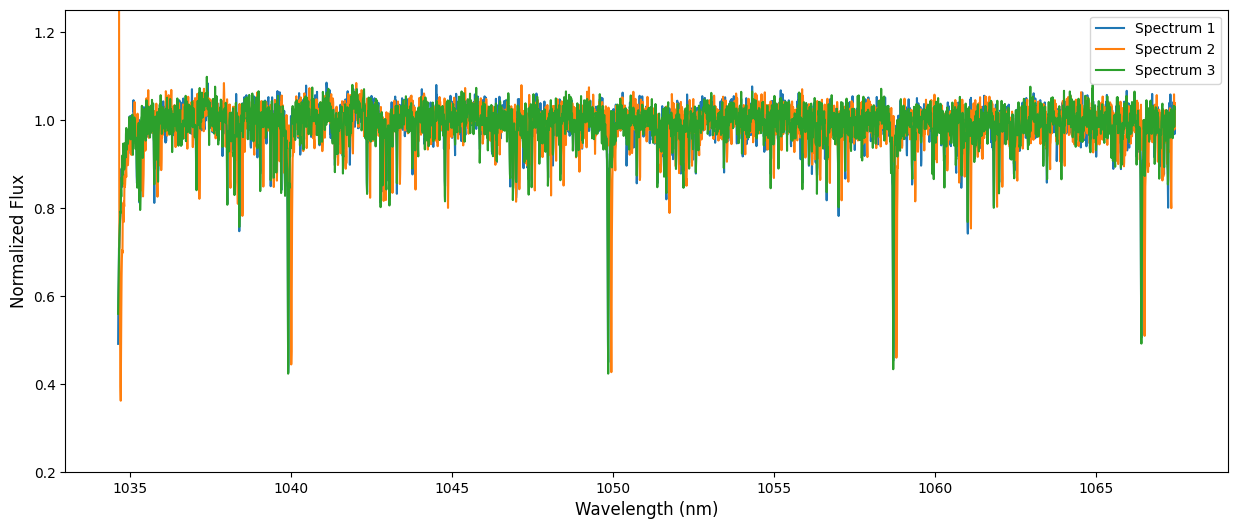

In [5]:
#plotting loop

plt.clf() 
plt.figure(figsize = (15, 6))

for i in range(nspec):
    plt.plot(inst_wgrid, synthetic_spectra[i,] , label = f'Spectrum {i + 1}')
    
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Normalized Flux', fontsize = 12)
plt.legend()
plt.ylim(0.2, 1.25)
plt.show()

## Plotting the Barnard's Star Observations

In [6]:
from astropy.io import fits

In [7]:
barnards_data_filepath = '../data/Barnard_Star_Data_Etienne/'
with fits.open(barnards_data_filepath + '2746683t.fits') as hdul:
    hdul.info()
    primary_header = hdul[0].header
    fluxab_header = hdul[1].header
    print(f'The BERV of this observation is: {fluxab_header["BERV"]} km/s')
    snr_key = f"EXTSN{order:03d}"
    snr = fluxab_header[snr_key]

    print(f"SNR for order {order}: {snr}")  
    
    wavelength = hdul['WaveAB'].data[order, :] # get the wavelengths
    flux = hdul['FluxAB'].data[order, : ] # also get flux
    blaze_correction = hdul['BlazeAB'].data[order, :] #get the blaze correction

    
#display(data)

Filename: ../data/Barnard_Star_Data_Etienne/2746683t.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     516   ()      
  1  FluxAB        1 ImageHDU      1154   (4088, 49)   float64   
  2  WaveAB        1 ImageHDU       809   (4088, 49)   float64   
  3  BlazeAB       1 ImageHDU       358   (4088, 49)   float64   
  4  Recon         1 ImageHDU      1154   (4088, 49)   float64   
  5  OHLine        1 ImageHDU      1150   (4088, 49)   float64   
  6  FluxA         1 ImageHDU      1154   (4088, 49)   float64   
  7  WaveA         1 ImageHDU       809   (4088, 49)   float64   
  8  BlazeA        1 ImageHDU       358   (4088, 49)   float64   
  9  FluxB         1 ImageHDU      1154   (4088, 49)   float64   
 10  WaveB         1 ImageHDU       809   (4088, 49)   float64   
 11  BlazeB        1 ImageHDU       358   (4088, 49)   float64   
The BERV of this observation is: 23.835342056940647 km/s
SNR for order 6: 106.40733079579289


In [8]:
len(wavelength)
print(len(flux))

4088


In [9]:
print(wavelength)

[1034.63617537 1034.64518693 1034.65419802 ... 1067.43381853 1067.44086322
 1067.44790742]


In [10]:
print(blaze_correction)
nan_count = np.isnan(flux).sum()
flux_blaze_corrected = flux/blaze_correction
print(f'The number of NaNs in the flux data is {nan_count}')

[nan nan nan ... nan nan nan]
The number of NaNs in the flux data is 1508


In [11]:
print(np.isnan(wavelength))

[False False False ... False False False]


### This is me attempting to normalize the spectrum
Doing the same idea that is seen in the realstar_synthetic_observations file

In [12]:
nan_mask = ~np.isnan(wavelength) & ~np.isnan(flux_blaze_corrected)
wave_clean = wavelength[nan_mask]
flux_clean = flux_blaze_corrected[nan_mask]

nbins = 100
bins = np.linspace(wave_clean.min(), wave_clean.max(), nbins + 1)
inds = np.digitize(wave_clean, bins)

In [13]:
w_med = [] ; f_med = []
for i in range(1, nbins + 1):
    bin_mask = (inds == i)
    if np.any(bin_mask):
        w_med.append(np.median(wave_clean[bin_mask]))
        f_med.append(np.median(flux_clean[bin_mask]))

w_med = np.array(w_med)
f_med = np.array(f_med)

In [14]:
coeffs = np.polyfit(w_med, f_med, 1)
continuum = np.polyval(coeffs, wave_clean)

In [15]:
flux_normalized_clean = flux_clean / continuum
flux_normalized_clean = flux_normalized_clean / np.median(flux_normalized_clean)

norm_flux = np.full_like(flux_blaze_corrected, np.nan)
norm_flux[nan_mask] = flux_normalized_clean

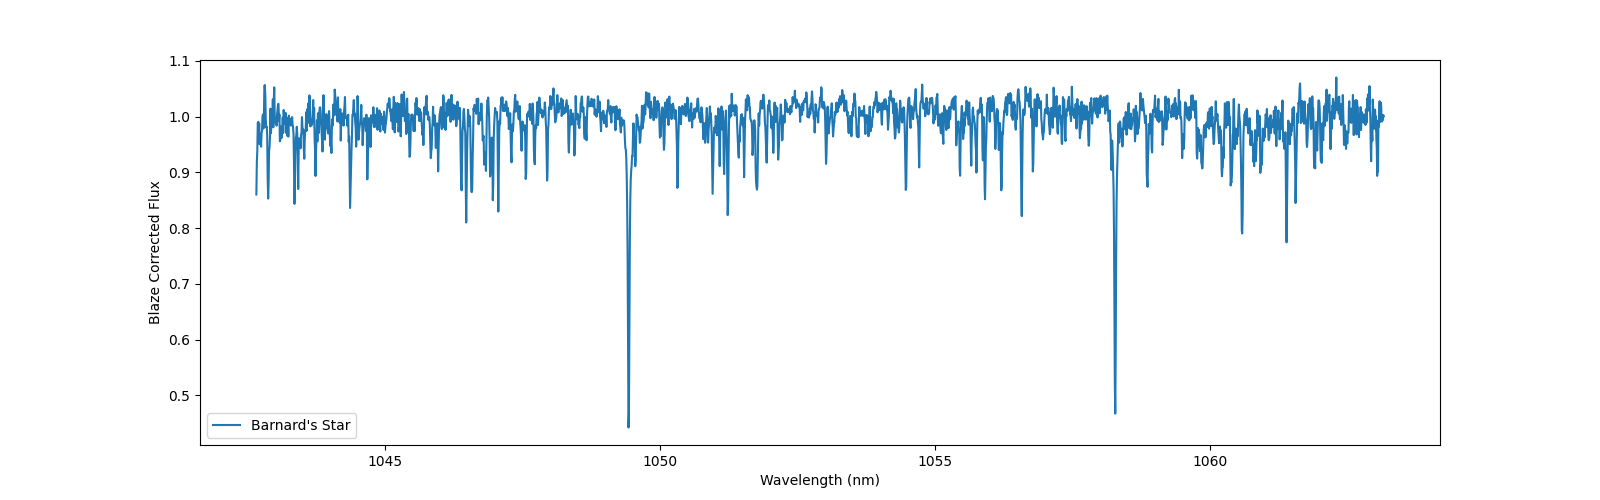

In [27]:
#plot the normalized spectrum
plt.figure(figsize = (16, 5))
plt.plot(wavelength, norm_flux, label="Barnard's Star")
plt.xlabel('Wavelength (nm)')
plt.ylabel('Blaze Corrected Flux')
plt.legend()
plt.show()

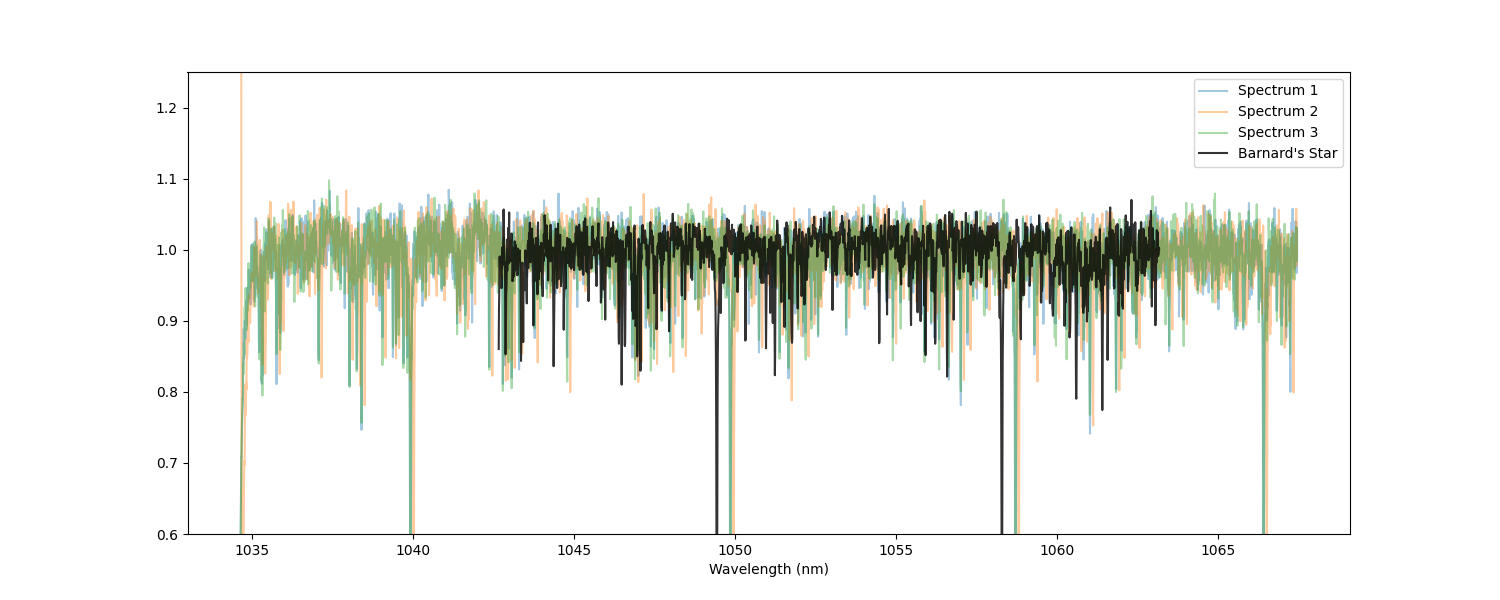

In [22]:
%matplotlib widget

#this is a terrible plot right now
plt.figure(figsize = (15, 6))
for i in range(nspec):
    plt.plot(inst_wgrid, synthetic_spectra[i,] , label = f'Spectrum {i + 1}', alpha = 0.4)
plt.plot(wavelength,norm_flux, label="Barnard's Star", color = 'black', alpha = 0.8)
plt.ylim(0.6,1.25)
plt.legend()
plt.xlabel('Wavelength (nm)')
plt.show()